In [3]:
# ============================================================
# MARKETING FUNNEL & CONVERSION PERFORMANCE ANALYSIS
# Step-by-step Python script 
# ============================================================

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.color": "#e0e0e0",
    "grid.linestyle": "--",
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})



In [4]:


DATA_DIR = "/Users/promojz/Documents/FutureInterns/FUTURE_DS_03/Data/"   

campaign   = pd.read_csv(DATA_DIR + "CAMPAIGN_TOUCH.csv", parse_dates=["touch_date"])
customer   = pd.read_csv(DATA_DIR + "CUSTOMER.csv",       parse_dates=["signup_date"])
mkt_ch     = pd.read_csv(DATA_DIR + "MARKETING_CHANNEL.csv")
support    = pd.read_csv(DATA_DIR + "SUPPORT_TICKET.csv", parse_dates=["created_date"])
store      = pd.read_csv(DATA_DIR + "STORE.csv")
channel    = pd.read_csv(DATA_DIR + "CHANNEL.csv")
product    = pd.read_csv(DATA_DIR + "PRODUCT.csv")
category   = pd.read_csv(DATA_DIR + "CATEGORY.csv")
promotion  = pd.read_csv(DATA_DIR + "PROMOTION.csv")
price_ch   = pd.read_csv(DATA_DIR + "PRICE_CHANGE.csv")

print("All files loaded.")
print(f"  campaign rows   : {len(campaign):,}")
print(f"  customer rows   : {len(customer):,}")
print(f"  support rows    : {len(support):,}")

All files loaded.
  campaign rows   : 280,103
  customer rows   : 10,000
  support rows    : 1,600


In [5]:
# ────────────────────────────────────────────────────────────
#  Quick data inspection
# ────────────────────────────────────────────────────────────

print("=== CAMPAIGN_TOUCH ===")
display(campaign.head(3))
print(campaign.dtypes)

print("\n=== CUSTOMER ===")
display(customer.head(3))

print("\n=== MARKETING_CHANNEL ===")
display(mkt_ch)

=== CAMPAIGN_TOUCH ===


,touch_id,customer_id,touch_date,channel,campaign_name,outcome
0,CT000000001,CUST000001,2023-05-08,Email,Health Bundle Offer,Ignored
1,CT000000002,CUST000001,2024-01-14,SMS,Weekend Deal,Ignored
2,CT000000003,CUST000001,2024-08-22,Push,Subscribe & Save,Ignored


touch_id                 object
customer_id              object
touch_date       datetime64[ns]
channel                  object
campaign_name            object
outcome                  object
dtype: object

=== CUSTOMER ===


,customer_id,signup_date,city,state,segment,status
0,CUST000001,2023-12-08,Cuttack,Odisha,Value,active
1,CUST000002,2023-03-22,Durgapur,West Bengal,Mainstream,churned
2,CUST000003,2023-11-21,Panipat,Haryana,Mainstream,churned



=== MARKETING_CHANNEL ===


,channel_id,channel_name,channel_type,cost_tier
0,MKT001,Email,Owned,Low
1,MKT002,SMS,Owned,Low
2,MKT003,Push,Owned,Low
3,MKT004,WhatsApp,Owned,Low
4,MKT005,Search Ads,Paid,High
5,MKT006,Social Ads,Paid,High
6,MKT007,Display Ads,Paid,Medium
7,MKT008,Affiliate,Paid,Medium
8,MKT009,Influencer,Paid,High
9,MKT010,Marketplace Banner,Paid,Medium


In [6]:
# ────────────────────────────────────────────────────────────
# Top-level funnel metrics
# ────────────────────────────────────────────────────────────

total       = len(campaign)
converted   = (campaign["outcome"] == "Converted").sum()
clicked     = (campaign["outcome"] == "Clicked").sum()
ignored     = (campaign["outcome"] == "Ignored").sum()
engaged     = clicked + converted          # anyone who did NOT ignore
conv_rate   = converted / total * 100
ctr         = clicked   / total * 100
ignore_rate = ignored   / total * 100
click_to_conv = converted / engaged * 100  # of those who engaged, how many converted

print("=" * 45)
print("      FUNNEL SUMMARY")
print("=" * 45)
print(f"  Total touches     : {total:>10,}")
print(f"  Ignored           : {ignored:>10,}  ({ignore_rate:.1f}%)")
print(f"  Engaged (clicked) : {clicked:>10,}  ({ctr:.1f}%)")
print(f"  Converted         : {converted:>10,}  ({conv_rate:.1f}%)")
print(f"  Click-to-convert  : {click_to_conv:.1f}%  (of engaged users)")
print("=" * 45)

      FUNNEL SUMMARY
  Total touches     :    280,103
  Ignored           :    252,078  (90.0%)
  Engaged (clicked) :     13,936  (5.0%)
  Converted         :     14,089  (5.0%)
  Click-to-convert  : 50.3%  (of engaged users)


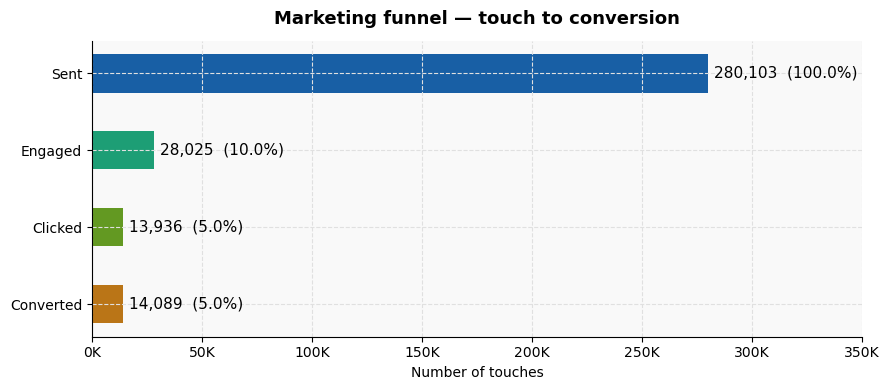

Saved: funnel_waterfall.png


In [26]:
import os
os.makedirs("../Python_Viz", exist_ok=True)
# ────────────────────────────────────────────────────────────
# Funnel waterfall chart
# ────────────────────────────────────────────────────────────

stages  = ["Sent", "Engaged", "Clicked", "Converted"]
values  = [total, engaged, clicked, converted]
colors  = ["#185FA5", "#1D9E75", "#639922", "#BA7517"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(stages[::-1], values[::-1], color=colors[::-1], height=0.5, edgecolor="none")

for bar, val in zip(bars, values[::-1]):
    ax.text(bar.get_width() + total * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,}  ({val/total*100:.1f}%)", va="center", fontsize=11)

ax.set_xlim(0, total * 1.25)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.set_xlabel("Number of touches")
ax.set_title("Marketing funnel — touch to conversion", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("../Python_Viz/funnel_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: funnel_waterfall.png")


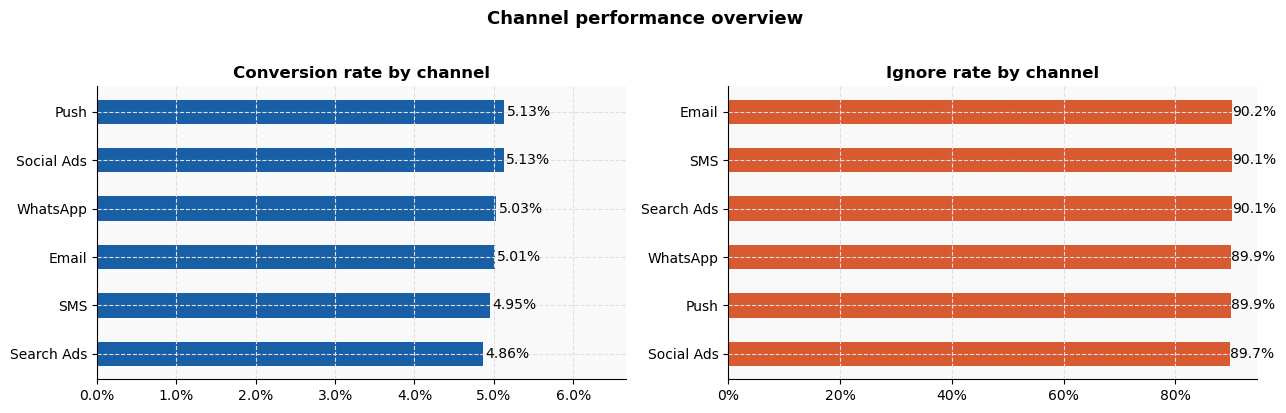

Saved: channel_performance.png


In [27]:
# ────────────────────────────────────────────────────────────
# Conversion rate by channel
# ────────────────────────────────────────────────────────────

ch_stats = (
    campaign
    .groupby("channel")["outcome"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .mul(100)
    .reset_index()
)

# Sort by conversion rate descending
ch_stats = ch_stats.sort_values("Converted", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: conversion rate bar
axes[0].barh(ch_stats["channel"], ch_stats["Converted"],
             color="#185FA5", height=0.5, edgecolor="none")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title("Conversion rate by channel", fontsize=12, fontweight="bold")
for i, (_, row) in enumerate(ch_stats.iterrows()):
    axes[0].text(row["Converted"] + 0.03, i, f"{row['Converted']:.2f}%", va="center", fontsize=10)
axes[0].set_xlim(0, ch_stats["Converted"].max() * 1.3)

# Right: ignore rate bar
ch_stats_sorted_ign = ch_stats.sort_values("Ignored", ascending=True)
axes[1].barh(ch_stats_sorted_ign["channel"], ch_stats_sorted_ign["Ignored"],
             color="#D85A30", height=0.5, edgecolor="none")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Ignore rate by channel", fontsize=12, fontweight="bold")
for i, (_, row) in enumerate(ch_stats_sorted_ign.iterrows()):
    axes[1].text(row["Ignored"] + 0.05, i, f"{row['Ignored']:.1f}%", va="center", fontsize=10)

plt.suptitle("Channel performance overview", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../Python_Viz/channel_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: channel_performance.png")

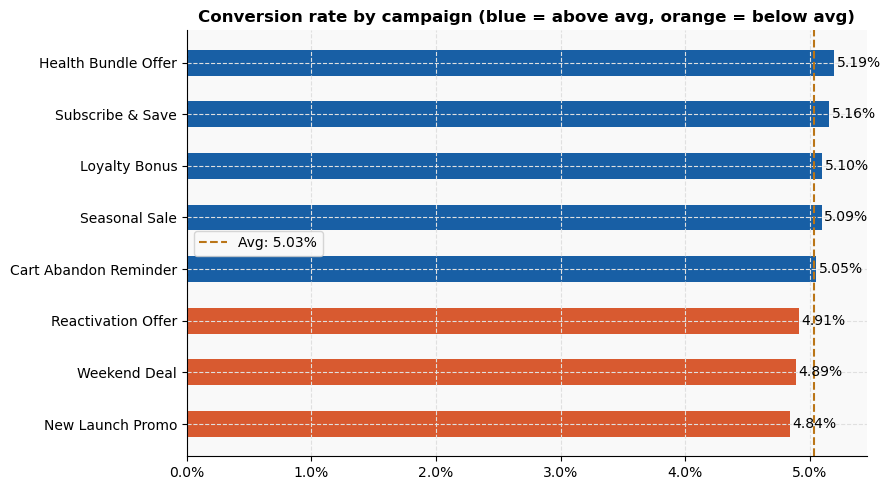

Saved: campaign_performance.png


In [28]:
# ────────────────────────────────────────────────────────────
# Conversion rate by campaign
# ────────────────────────────────────────────────────────────

camp_stats = (
    campaign
    .groupby("campaign_name")["outcome"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .mul(100)
    .reset_index()
    .sort_values("Converted", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors_camp = ["#D85A30" if v < camp_stats["Converted"].mean() else "#185FA5"
               for v in camp_stats["Converted"]]
ax.barh(camp_stats["campaign_name"], camp_stats["Converted"],
        color=colors_camp, height=0.5, edgecolor="none")

# Average line
avg = camp_stats["Converted"].mean()
ax.axvline(avg, color="#BA7517", linestyle="--", linewidth=1.5, label=f"Avg: {avg:.2f}%")

for i, (_, row) in enumerate(camp_stats.iterrows()):
    ax.text(row["Converted"] + 0.02, i, f"{row['Converted']:.2f}%", va="center", fontsize=10)

ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Conversion rate by campaign (blue = above avg, orange = below avg)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../Python_Viz/campaign_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: campaign_performance.png")


In [10]:
# ────────────────────────────────────────────────────────────
#  Merge customer data for segment analysis
# ────────────────────────────────────────────────────────────

merged = campaign.merge(
    customer[["customer_id", "segment", "status", "signup_date"]],
    on="customer_id",
    how="left"
)

print("Merged shape:", merged.shape)
print("Sample:")
display(merged.head(3))

Merged shape: (280103, 9)
Sample:


,touch_id,customer_id,touch_date,channel,campaign_name,outcome,segment,status,signup_date
0,CT000000001,CUST000001,2023-05-08,Email,Health Bundle Offer,Ignored,Value,active,2023-12-08
1,CT000000002,CUST000001,2024-01-14,SMS,Weekend Deal,Ignored,Value,active,2023-12-08
2,CT000000003,CUST000001,2024-08-22,Push,Subscribe & Save,Ignored,Value,active,2023-12-08


Conversion rate by segment:


outcome,segment,Converted,Clicked,Ignored
0,Health-focused,5.12,4.95,89.93
1,Mainstream,5.07,4.95,89.99
3,Value,5.01,5.03,89.96
2,Premium,4.95,4.92,90.13


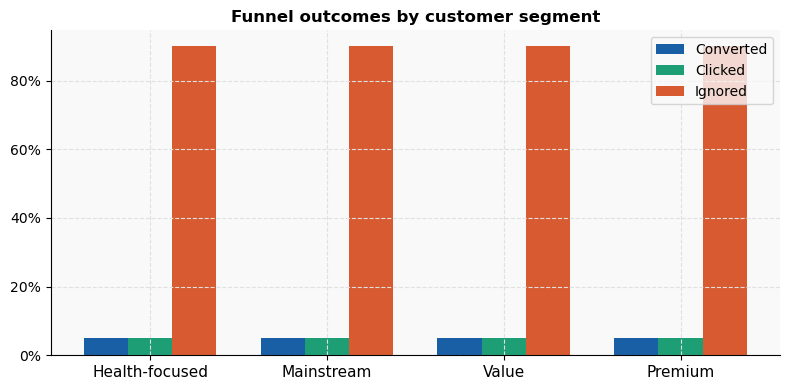

Saved: segment_funnel.png


In [29]:
# ────────────────────────────────────────────────────────────
# Conversion by customer segment
# ────────────────────────────────────────────────────────────

seg_conv = (
    merged
    .groupby("segment")["outcome"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .mul(100)
    .reset_index()
    .sort_values("Converted", ascending=False)
)

print("Conversion rate by segment:")
display(seg_conv[["segment", "Converted", "Clicked", "Ignored"]].round(2))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(seg_conv))
width = 0.25

ax.bar(x - width, seg_conv["Converted"], width, label="Converted", color="#185FA5", edgecolor="none")
ax.bar(x,         seg_conv["Clicked"],   width, label="Clicked",   color="#1D9E75", edgecolor="none")
ax.bar(x + width, seg_conv["Ignored"],   width, label="Ignored",   color="#D85A30", edgecolor="none")

ax.set_xticks(x)
ax.set_xticklabels(seg_conv["segment"], fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Funnel outcomes by customer segment", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../Python_Viz/segment_funnel.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: segment_funnel.png")

Conversion rate by status:


outcome,status,Clicked,Converted,Ignored
0,active,4.98,5.03,89.99
1,churned,4.95,5.03,90.02


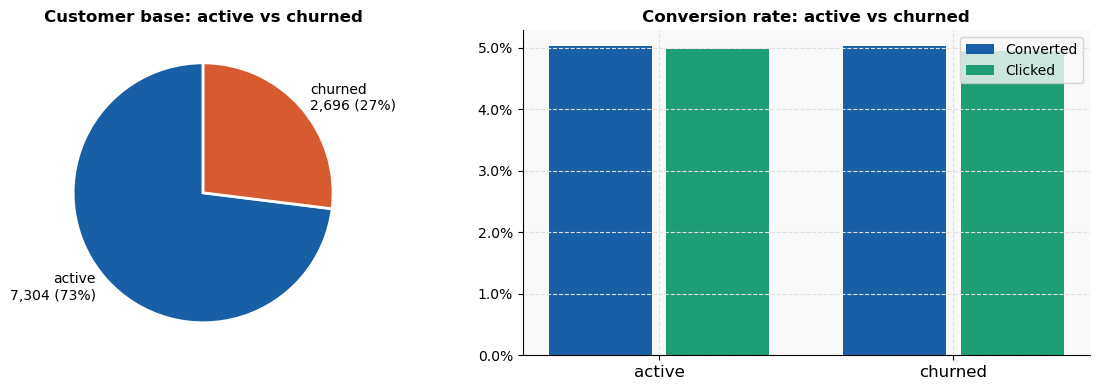

Saved: status_analysis.png


In [30]:
# ────────────────────────────────────────────────────────────
# Conversion by customer status (active vs churned)
# ────────────────────────────────────────────────────────────

status_conv = (
    merged
    .groupby("status")["outcome"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .mul(100)
    .reset_index()
)

print("Conversion rate by status:")
display(status_conv.round(2))

# Customer status distribution pie
status_dist = customer["status"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(status_dist.values,
            labels=[f"{k}\n{v:,} ({v/len(customer)*100:.0f}%)" for k, v in status_dist.items()],
            colors=["#185FA5", "#D85A30"], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Customer base: active vs churned", fontsize=12, fontweight="bold")

# Bar: conversion rate per status
x2 = np.arange(len(status_conv))
axes[1].bar(x2 - 0.2, status_conv["Converted"], 0.35, label="Converted", color="#185FA5")
axes[1].bar(x2 + 0.2, status_conv["Clicked"],   0.35, label="Clicked",   color="#1D9E75")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(status_conv["status"], fontsize=12)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Conversion rate: active vs churned", fontsize=12, fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.savefig("../Python_Viz/status_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: status_analysis.png")


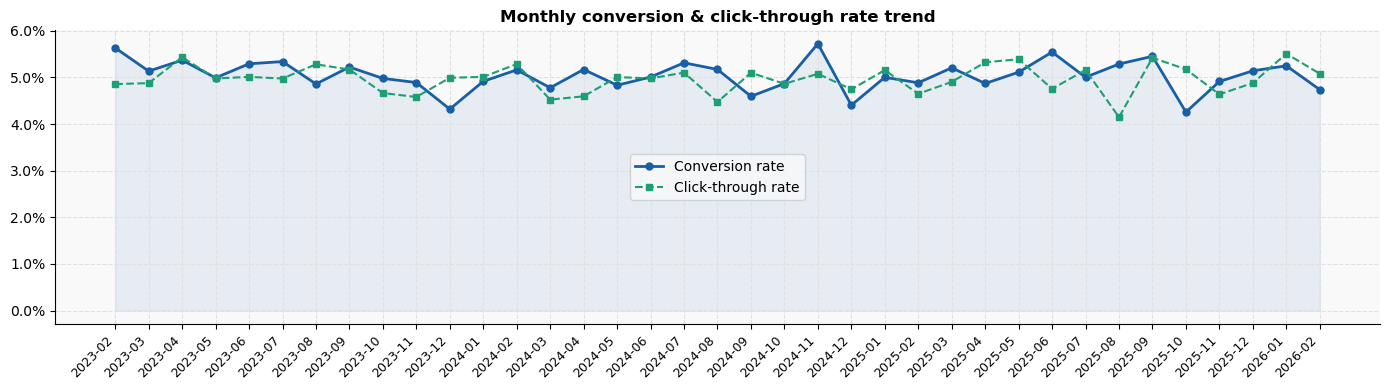

Saved: monthly_trend.png


In [35]:
# ────────────────────────────────────────────────────────────
# Monthly conversion trend
# ────────────────────────────────────────────────────────────

campaign["month"] = campaign["touch_date"].dt.to_period("M")

monthly = (
    campaign
    .groupby("month")["outcome"]
    .value_counts()
    .unstack(fill_value=0)
)
monthly["conv_rate"] = monthly["Converted"] / monthly.sum(axis=1) * 100
monthly["ctr"]       = monthly["Clicked"]   / monthly.sum(axis=1) * 100
monthly.index = monthly.index.astype(str)

fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(monthly.index, monthly["conv_rate"], color="#185FA5",
         marker="o", markersize=5, linewidth=2, label="Conversion rate")
ax1.plot(monthly.index, monthly["ctr"],       color="#1D9E75",
         marker="s", markersize=4, linewidth=1.5, linestyle="--", label="Click-through rate")
ax1.fill_between(monthly.index, monthly["conv_rate"], alpha=0.08, color="#185FA5")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_title("Monthly conversion & click-through rate trend", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("../Python_Viz/monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: monthly_trend.png")

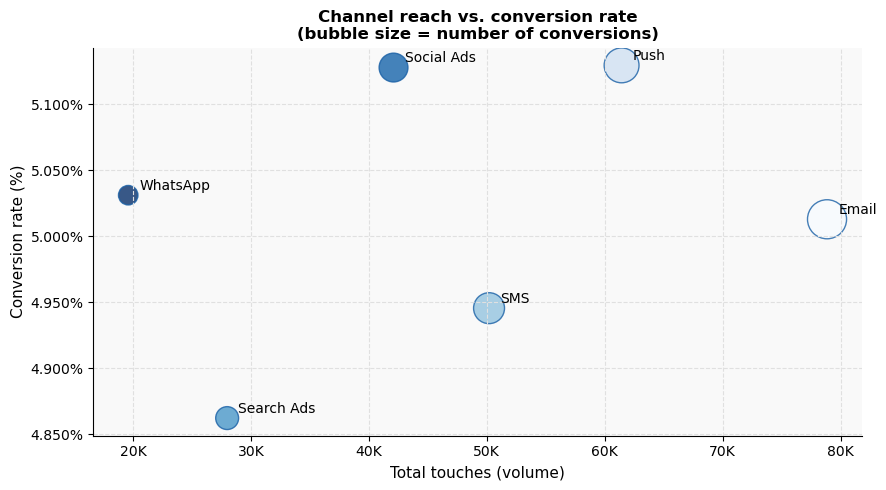

Saved: channel_bubble.png


In [31]:
# ────────────────────────────────────────────────────────────
# Channel reach vs. conversion volume (bubble chart)
# ────────────────────────────────────────────────────────────

ch_volume = campaign.groupby("channel").agg(
    total_touches=("outcome", "count"),
    converted=("outcome", lambda x: (x == "Converted").sum()),
    clicked=("outcome",   lambda x: (x == "Clicked").sum()),
).reset_index()
ch_volume["conv_rate"] = ch_volume["converted"] / ch_volume["total_touches"] * 100

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    ch_volume["total_touches"],
    ch_volume["conv_rate"],
    s=ch_volume["converted"] / 5,      # bubble size = converted volume
    c=range(len(ch_volume)),
    cmap="Blues",
    alpha=0.8,
    edgecolors="#185FA5",
    linewidths=1
)

for _, row in ch_volume.iterrows():
    ax.annotate(row["channel"],
                (row["total_touches"], row["conv_rate"]),
                xytext=(8, 4), textcoords="offset points", fontsize=10)

ax.set_xlabel("Total touches (volume)", fontsize=11)
ax.set_ylabel("Conversion rate (%)", fontsize=11)
ax.set_title("Channel reach vs. conversion rate\n(bubble size = number of conversions)",
             fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig("../Python_Viz/channel_bubble.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: channel_bubble.png")

Support ticket summary:
  Total tickets         : 1,600
  Resolved              : 1,384
  Open                  : 166
  Escalated             : 50
  Avg CSAT score        : 4.36 / 5
  Avg resolution hrs    : 17.6


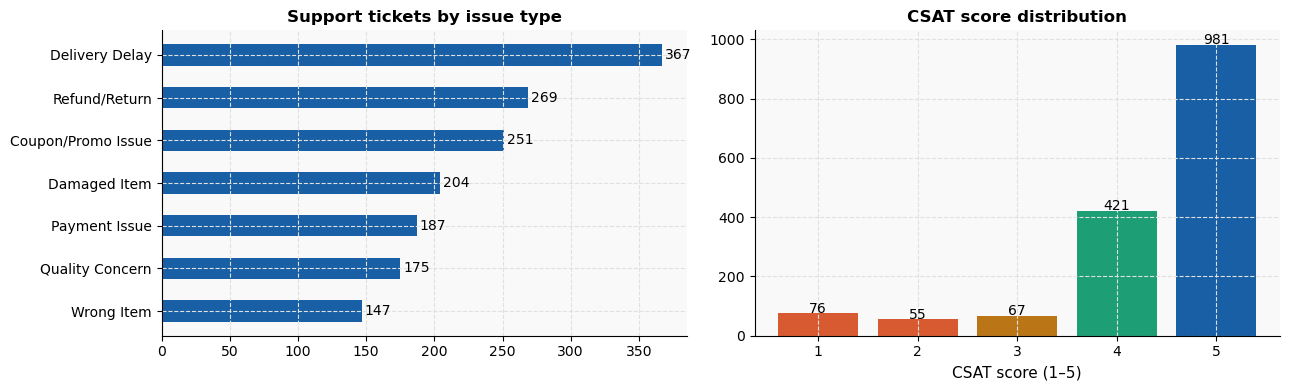

Saved: support_analysis.png


In [32]:
# ────────────────────────────────────────────────────────────
# Support ticket analysis
# ────────────────────────────────────────────────────────────

print("Support ticket summary:")
print(f"  Total tickets         : {len(support):,}")
print(f"  Resolved              : {(support['status']=='Resolved').sum():,}")
print(f"  Open                  : {(support['status']=='Open').sum():,}")
print(f"  Escalated             : {(support['status']=='Escalated').sum():,}")
print(f"  Avg CSAT score        : {support['csat_score'].mean():.2f} / 5")
print(f"  Avg resolution hrs    : {support['resolution_time_hr'].mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Issue type bar
issue_counts = support["issue_type"].value_counts().sort_values()
axes[0].barh(issue_counts.index, issue_counts.values,
             color="#185FA5", height=0.5, edgecolor="none")
axes[0].set_title("Support tickets by issue type", fontsize=12, fontweight="bold")
for i, v in enumerate(issue_counts.values):
    axes[0].text(v + 2, i, str(v), va="center", fontsize=10)

# CSAT distribution
csat_counts = support["csat_score"].value_counts().sort_index()
csat_colors = ["#D85A30", "#D85A30", "#BA7517", "#1D9E75", "#185FA5"]
axes[1].bar(csat_counts.index, csat_counts.values,
            color=csat_colors, edgecolor="none")
axes[1].set_xlabel("CSAT score (1–5)", fontsize=11)
axes[1].set_title("CSAT score distribution", fontsize=12, fontweight="bold")
for i, (score, val) in enumerate(csat_counts.items()):
    axes[1].text(score, val + 2, str(val), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../Python_Viz/support_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: support_analysis.png")

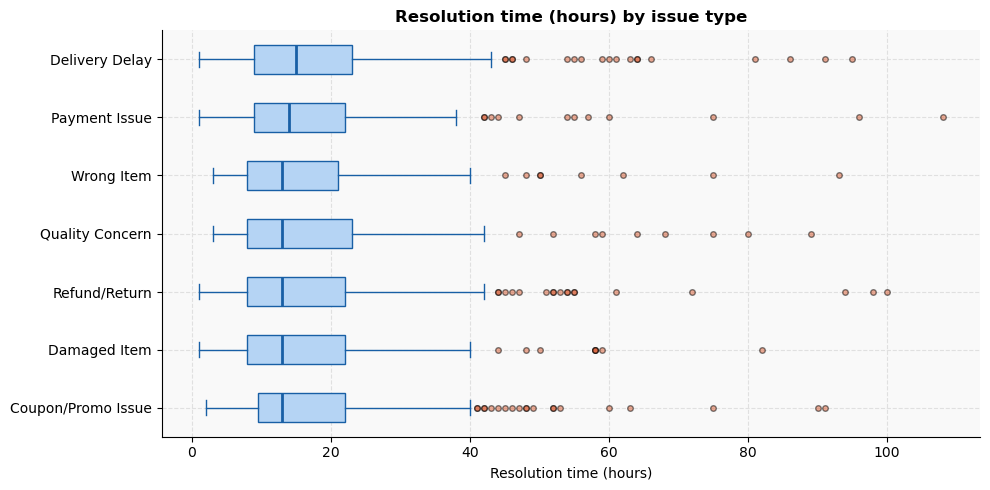

Saved: resolution_boxplot.png


In [33]:
# ────────────────────────────────────────────────────────────
# Resolution time by issue type (box plot) — FIXED
# ────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

# Get sorted order manually
issue_order = support.groupby("issue_type")["resolution_time_hr"].median().sort_values().index.tolist()

# Build list of arrays in the correct order
grouped_data = [support[support["issue_type"] == issue]["resolution_time_hr"].dropna().values
                for issue in issue_order]

bp = ax.boxplot(
    grouped_data,
    vert=False,
    patch_artist=True,
    labels=issue_order,
    boxprops=dict(facecolor="#B5D4F4", color="#185FA5"),
    medianprops=dict(color="#185FA5", linewidth=2),
    whiskerprops=dict(color="#185FA5"),
    capprops=dict(color="#185FA5"),
    flierprops=dict(marker="o", markerfacecolor="#D85A30", markersize=4, alpha=0.5)
)

ax.set_title("Resolution time (hours) by issue type", fontsize=12, fontweight="bold")
ax.set_xlabel("Resolution time (hours)")
plt.tight_layout()
plt.savefig("../Python_Viz/resolution_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: resolution_boxplot.png")

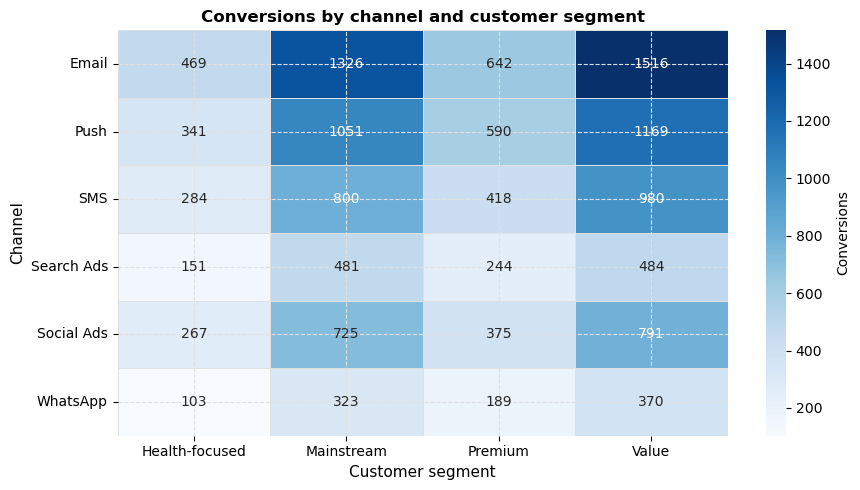

Saved: channel_segment_heatmap.png


In [34]:
# ────────────────────────────────────────────────────────────
# Channel x Segment heatmap (conversion counts)
# ────────────────────────────────────────────────────────────

heat_data = (
    merged[merged["outcome"] == "Converted"]
    .groupby(["channel", "segment"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    heat_data,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="#e0e0e0",
    ax=ax,
    cbar_kws={"label": "Conversions"}
)
ax.set_title("Conversions by channel and customer segment", fontsize=12, fontweight="bold")
ax.set_xlabel("Customer segment", fontsize=11)
ax.set_ylabel("Channel", fontsize=11)
plt.tight_layout()
plt.savefig("../Python_Viz/channel_segment_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: channel_segment_heatmap.png")


In [23]:
# ────────────────────────────────────────────────────────────
#Final summary table (export-ready)
# ────────────────────────────────────────────────────────────

summary = ch_volume[["channel", "total_touches", "converted", "clicked", "conv_rate"]].copy()
summary.columns = ["Channel", "Total Touches", "Converted", "Clicked", "Conversion Rate (%)"]
summary["Conversion Rate (%)"] = summary["Conversion Rate (%)"].round(2)
summary["Ignore Count"] = summary["Total Touches"] - summary["Converted"] - summary["Clicked"]
summary["Ignore Rate (%)"] = (summary["Ignore Count"] / summary["Total Touches"] * 100).round(2)
summary = summary.sort_values("Conversion Rate (%)", ascending=False).reset_index(drop=True)

print("FINAL CHANNEL SUMMARY TABLE:")
display(summary)

# Save to CSV
summary.to_csv("../Data/Tableau_Data/channel_summary.csv", index=False)
print("\nSaved: channel_summary.csv")

# Campaign summary
camp_summary = (
    campaign
    .groupby("campaign_name")["outcome"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .mul(100)
    .round(2)
    .reset_index()
    .sort_values("Converted", ascending=False)
)
camp_summary.to_csv("../Data/Tableau_Data/campaign_summary.csv", index=False)
print("Saved: campaign_summary.csv")

print("\n✓ All analysis complete. Charts and CSVs are saved in your working directory.")

FINAL CHANNEL SUMMARY TABLE:


,Channel,Total Touches,Converted,Clicked,Conversion Rate (%),Ignore Count,Ignore Rate (%)
0,Push,61429,3151,3076,5.13,55202,89.86
1,Social Ads,42084,2158,2187,5.13,37739,89.68
2,WhatsApp,19578,985,992,5.03,17601,89.90
3,Email,78856,3953,3811,5.01,71092,90.15
4,SMS,50186,2482,2469,4.95,45235,90.13
5,Search Ads,27970,1360,1401,4.86,25209,90.13



Saved: channel_summary.csv
Saved: campaign_summary.csv

✓ All analysis complete. Charts and CSVs are saved in your working directory.


In [24]:
import pandas as pd

campaign = pd.read_csv("../Data/CAMPAIGN_TOUCH.csv", parse_dates=["touch_date"])
customer = pd.read_csv("../Data/CUSTOMER.csv")

merged = campaign.merge(
    customer[["customer_id", "segment", "status"]], 
    on="customer_id", how="left"
)

# --- FILE 1: Funnel chart ---
funnel_data = pd.DataFrame({
    "Stage":  ["Sent", "Engaged", "Clicked", "Converted"],
    "Count":  [
        len(campaign),
        (campaign["outcome"] != "Ignored").sum(),
        (campaign["outcome"] == "Clicked").sum(),
        (campaign["outcome"] == "Converted").sum()
    ],
    "Order": [1, 2, 3, 4]
})
funnel_data["Pct_of_Total"] = (funnel_data["Count"] / len(campaign) * 100).round(2)
funnel_data.to_csv("../Data/Tableau_Data/tableau_funnel_stages.csv", index=False)
print("✓ tableau_funnel_stages.csv")

# --- FILE 2: Channel performance ---
ch = campaign.groupby("channel").agg(
    Total_Touches=("outcome", "count"),
    Converted=("outcome", lambda x: (x == "Converted").sum()),
    Clicked=("outcome",   lambda x: (x == "Clicked").sum()),
    Ignored=("outcome",   lambda x: (x == "Ignored").sum()),
).reset_index()
ch["Conversion_Rate_Pct"] = (ch["Converted"] / ch["Total_Touches"] * 100).round(2)
ch["Ignore_Rate_Pct"]     = (ch["Ignored"]   / ch["Total_Touches"] * 100).round(2)
ch["Click_Rate_Pct"]      = (ch["Clicked"]   / ch["Total_Touches"] * 100).round(2)
ch.to_csv("../Data/Tableau_Data/tableau_channel.csv", index=False)
print("✓ tableau_channel.csv")

# --- FILE 3: Monthly trend ---
campaign["Month"] = campaign["touch_date"].dt.to_period("M").astype(str)
monthly = campaign.groupby("Month").agg(
    Total_Touches=("outcome", "count"),
    Converted=("outcome", lambda x: (x == "Converted").sum()),
    Clicked=("outcome",   lambda x: (x == "Clicked").sum()),
).reset_index()
monthly["Conversion_Rate_Pct"] = (monthly["Converted"] / monthly["Total_Touches"] * 100).round(2)
monthly["Click_Rate_Pct"]      = (monthly["Clicked"]   / monthly["Total_Touches"] * 100).round(2)
monthly.to_csv("../Data/Tableau_Data/tableau_monthly_trend.csv", index=False)
print("✓ tableau_monthly_trend.csv")

# --- FILE 4: Segment heatmap ---
heatmap = (
    merged[merged["outcome"] == "Converted"]
    .groupby(["channel", "segment"])
    .size()
    .reset_index(name="Conversions")
)
total_by_ch_seg = (
    merged.groupby(["channel", "segment"])
    .size()
    .reset_index(name="Total_Touches")
)
heatmap = heatmap.merge(total_by_ch_seg, on=["channel", "segment"])
heatmap["Conversion_Rate_Pct"] = (heatmap["Conversions"] / heatmap["Total_Touches"] * 100).round(2)
heatmap.to_csv("../Data/Tableau_Data/tableau_segment_heatmap.csv", index=False)
print("✓ tableau_segment_heatmap.csv")

print("\nAll 4 Tableau files ready!")

✓ tableau_funnel_stages.csv
✓ tableau_channel.csv
✓ tableau_monthly_trend.csv
✓ tableau_segment_heatmap.csv

All 4 Tableau files ready!
